# Imports

In [2]:
# Usual stuff
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Path
from pathlib import Path

# HDF5
import h5py

# RegEx
import re

# Speed Plot

[32 16  8  4  2  1]
[0. 0. 0. 0. 0. 1.]


C:\Users\guilh\AppData\Local\Temp\ipykernel_24728\1210461087.py:20: RuntimeWarning: divide by zero encountered in divide
  plt.plot(tt, 1/ss)


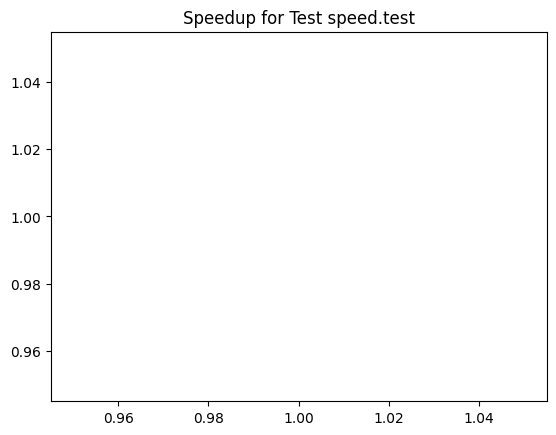

In [ ]:
# Get the directory where the script is located
current_dir = Path.cwd()

# Get the output directory
current_out = current_dir

for filepath in current_out.iterdir():
    if filepath.is_file() and str(filepath.suffix) == ".test":

        # Open the HDF5 file in read mode
        with h5py.File(filepath, "r") as file:
            
            # Read parameters group into numpy arrays
            tt = file["tt_data"][()]
            rr = file["ss_data"][()]

            # Sort the arrays by runtime
            sort_indices = np.argsort(tt)

            # View those arrays in the sorted order
            tt = tt[sort_indices]
            rr = rr[sort_indices]

            # Get the speedup
            ss = rr[0] / rr

            plt.plot(tt, ss/tt)
            plt.xlabel("Number of Threads")
            plt.ylabel("Speedup per Thread")
            plt.title(f"Speedup for Test {filepath.name}")
            plt.show()